# 🏠⚡ Home Energy Management Systems (Home EMS)

## 1. What is a Home Energy Management System? 🤖

A **Home Energy Management System (EMS)** is a smart controller that supervises and optimizes how energy is:

* **Produced** (e.g., rooftop PV ☀️),
* **Stored** (e.g., home battery 🔋),
* **Consumed** (household appliances, heating, EV charging 🧺🚗),
* **Exchanged with the grid** (buying and selling electricity 🔄).

You can think of it as a **“traffic controller” for electricity** in the home: it constantly monitors the system and decides where energy should flow.

Typical commercial EMS solutions include systems from **ENPHASE** and **LG Electronics**, among others.

---

## 2. Why Do We Need a Home EMS? ❓

Modern households often have:

* Rooftop **solar PV** ☀️
* **Electric vehicles (EVs)** 🚗🔌
* **Batteries** 🔋
* **Time-varying electricity tariffs** (time-of-use pricing) ⏰💶

Without a smart EMS:

* Solar energy might be **wasted** (if not used or stored when generated),
* Electricity **bills may stay high**,
* The **battery and EV** may be used in a suboptimal way.

A Home EMS helps to:

* 💰 **Reduce annual electricity bills**
* ☀️ **Maximize self-consumption of PV** (use your own solar instead of buying from the grid)
* 🌍 Optionally **reduce carbon footprint** or **support backup power** during outages.

---

## 3. Main Components of a Home EMS 🧩

Conceptual components (see Fig. 2 in the description):

1. **Solar PV Panels (PV)** ☀️

   * Generate renewable energy.

2. **Battery Energy Storage System (BESS)** 🔋

   * Stores surplus energy and supplies energy when needed.

3. **Power Electronics** 🔌

   * Inverters, converters, and controllers that manage AC/DC conversions and safe power flows.

4. **Intelligent Supervisory System (Optimization Algorithm)** 🧠

   * Software that decides **how much power** to:

     * Take from the grid,
     * Store in / draw from the battery,
     * Use directly from PV,
     * Export back to the grid.

These decisions are computed based on **optimization goals**, **constraints**, and **forecasts** (load, PV, prices, etc.).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Var, NonNegativeReals, Reals,
    Objective, Constraint, ConstraintList, RangeSet,
    minimize, SolverFactory, value, inequality
)

# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True


## Data loading helper 

The CSV is expected to have the following relevant columns:

- `time` – timestamp (hourly)
- `el_price` – electricity price (€/kWh)
- `consumption` – household consumption (kW)
- `pv_production` – PV production (kW or normalized units)

We **rename** these to the same names used by the EMS model:

- `Price`
- `Demand`
- `PV Generation`


In [2]:
def load_kaggle_ems_data(path="kaggle_competition_dataset_with_pv.csv"):
    """Load Kaggle-style EMS dataset and standardize column names.

    Parameters
    ----------
    path : str
        Path to `kaggle_competition_dataset_with_pv.csv`.
    rescale_pv_to_kw : bool
        If True, rescale `pv_production` so that its maximum equals `pv_max_kw`.
    pv_max_kw : float
        Target maximum PV output after rescaling (kW).
    """
    df = pd.read_csv(path, parse_dates=["time"])
    df = df.set_index("time").sort_index()

    # Rename to match EMS model expectations
    df = df.rename(columns={
        "el_price": "Price",
        "consumption": "Demand",
        "pv_production": "PV Generation",
    })


    return df


---

## 4. Optimization Problem: Minimizing Electricity Cost 📉

We consider a simple but realistic goal:

> **Minimize the  electricity bill** using optimal control of grid, PV, and battery.

The optimization is typically run for a **prediction horizon** (e.g. next 24 hours with hourly or 15-min resolution) and repeated continuously (e.g. rolling horizon).

### 4.1 Objective Function 🎯

Let:

* $ n $ – number of time steps in the optimization window (e.g. $ n=24 $ for 24 hours),
* $ t = 1, \dots, n $ – time step index.

We define the **total electricity cost** over the horizon:

$$
\min_{\mathcal{F}} \sum_{t=1}^{n} \big( Grc_t - GrP_t \big)
$$

where:

* $ Grc_t $ – cost of **buying** electricity from the grid at time $ t $,
* $ GrP_t $ – **profit** from **selling** (exporting) electricity to the grid at time $ t $,
* $ \mathcal{F} $ – vector of decision variables (e.g. grid power, battery power).

So the EMS tries to **minimize net payment to the grid**, taking into account both purchases and sales.

---

### 4.2 Decision Variables 🔢

Typical decision variables at each time step $ t $:

* $ P_{Gr}[t] $ – grid power flow (positive = import, negative = export),
* $ P_{BESS}[t] $ – battery power (positive = discharge to house, negative = charging),
* (Optionally) split of **PV generation** into:

  * Direct consumption,
  * Battery charging,
  * Export to grid.

All these form the optimization vector $ \mathcal{F} $.

---

### 4.3 Cost of Buying and Selling Energy 💶

Let:

* $ E_{Gr,t} $ – net **energy** taken from the grid during time step $ t $,
* $ UToU_t $ – **time-of-use tariff** (€/kWh) at time $ t $,
* $ \gamma \in [0,1] $ – **Feed-in Tariff (FiT) coefficient**, representing the fraction of the purchase price you receive when exporting to the grid (e.g. 0.8 = 20% below the purchase price).

**Buying from the grid** (import, $ P_{Gr}[t] > 0 $):

$$
Grc_t = E_{Gr,t} \cdot UToU_t, \quad \text{if } P_{Gr}[t] > 0
$$

**Selling to the grid** (export, $ P_{Gr}[t] < 0 $):

$$
GrP_t = \big( E_{Gr,t} \cdot UToU_t \big) \cdot \gamma, \quad \text{if } P_{Gr}[t] < 0
$$

So the EMS earns money when exporting, but usually at a **lower rate** than the purchase price (FiT < 1).

---

### 4.4 From Power to Energy ⏱️

Energy is power integrated over time:

$$
E = P \cdot \Delta t
$$

With constant time step and system conditions, we can compute:

$$
E_{Gr,t} = P_{Gr}[t] \cdot S
$$

where:

* $ S $ – duration of each step in seconds:

  * Hourly: $ S = 60 \times 60 $,
  * 15-min: $ S = 15 \times 60 $.

This lets us formulate the optimization in terms of **power variables** with a fixed time step.

---

## 5. System Constraints 🧱

To ensure **physical feasibility** and safe operation, we impose constraints based on:

* PV system capacity,
* Battery capacity and charge/discharge limits,
* Grid connection limits,
* Battery SoC bounds,
* Power balance.

### 5.1 Example Household Configuration 🏡

Assume:

* PV: max **5 kW**,
* Battery: **10 kWh** capacity, **±5 kW** charge/discharge,
* Grid: max **±5 kW**.

Then we must enforce:

1. **Grid power limits**:

$$
\forall t,\quad -5 ,\text{kW} \le P_{Gr}[t] \le 5 ,\text{kW}
$$

2. **Battery power limits**:

$$
\forall t,\quad -5 ,\text{kW} \le P_{BESS}[t] \le 5 ,\text{kW}
$$

(Here sign convention can be chosen; the key is to limit magnitude.)

3. **Power balance** (supply = demand):

$$
\forall t,\quad P_{Gr}[t] + P_{BESS}[t] + P_{PV}[t] = P_{L}[t]
$$

where:

* $ P_{PV}[t] $ – PV generation at time $ t $ (from forecast or measured profile),
* $ P_{L}[t] $ – household load at time $ t $.

4. **Battery energy (SoC) bounds**:

Let $ E_{BESS}[t] $ be stored energy in the battery:

$$
\forall t,\quad E_{BESS}^{\min} \le E_{BESS}[t] \le E_{BESS}^{\max}
$$

Alternatively, define **State of Charge (SoC)**:

$$
\forall t,\quad SoC_{\min} \le SoC_{BESS}[t] \le SoC_{\max}
$$

Typical practical values:

* $ SoC_{\min} \approx 15% $ (avoid deep discharge),
* $ SoC_{\max} \approx 90% $ (avoid overcharge).

These protect the battery and extend its lifetime.



## 🧮 Quick intro to Pyomo

**Pyomo** is a Python-based, open-source library for building and solving **optimization models**.
You use it to describe your problem in math-like form (variables, constraints, objective), and then connect it to a solver (e.g. CBC, GLPK, IPOPT, Gurobi, CPLEX).

---

### ⭐ What you can do with Pyomo

* 🔢 **Linear / Mixed-Integer** optimization (LP, MILP)
* 🔄 **Nonlinear** optimization (NLP, MINLP)
* 🧱 Build models in a **modular, readable** way inside normal Python code

---

### 🧩 Core building blocks

In a typical Pyomo script you define:

* `ConcreteModel()` – the model container 📦
* **Sets** – indices for time, devices, etc.
* **Parameters** – data (prices, loads, PV, capacities)
* **Variables** – decision variables (grid power, battery power, SoC, …)
* **Constraints** – equations/inequalities (power balance, limits, SoC bounds)
* **Objective** – what to minimize or maximize (e.g. total cost 💶)

---


In [6]:
def optimize_ems_pyomo(
    df,
    bess_capacity_kwh=10.0,
    batt_p_ch_max_kw=5.0,
    batt_p_dis_max_kw=5.0,
    grid_p_max_kw=5.0,
    bess_init_kwh=5.0,
    bess_min_kwh=0.5,
    bess_max_kwh=9.5,
    gamma=0.8,
    solver_name="highs",
    verbose=False,
):
    """Single-shot EMS optimization using Pyomo.

    Expects df to contain columns:
    - 'Price'
    - 'Demand'
    - 'PV Generation'
    """
    dt = 1.0  # hours per timestep (hourly data)
    T = len(df)

    price = df["Price"].values.astype(float)
    demand = df["Demand"].values.astype(float)
    pv = df["PV Generation"].values.astype(float)

    # ------------------------------------------------------------------
    # Pyomo model
    # ------------------------------------------------------------------
    m = ConcreteModel()

    # Time indices: 0 .. T-1
    m.T = RangeSet(0, T - 1)
    # Battery energy indices: 0 .. T  (T+1 states)
    m.Tsoc = RangeSet(0, T)

    # Decision variables
    m.P_grid_pos = Var(m.T, domain=NonNegativeReals)   # grid import (kW)
    m.P_grid_neg = Var(m.T, domain=NonNegativeReals)   # grid export (kW)
    m.P_charge   = Var(m.T, domain=NonNegativeReals)   # battery charging power (kW)
    m.P_discharge = Var(m.T, domain=NonNegativeReals)  # battery discharging power (kW)
    m.bess_energy = Var(m.Tsoc, domain=Reals)          # state of charge (kWh-like units)

    # ------------------------------------------------------------------
    # Objective: minimize cost of energy = import*price - gamma*export*price
    # ------------------------------------------------------------------
    def obj_rule(model):
        return sum(
            (model.P_grid_pos[t] * price[t] * dt
             - model.P_grid_neg[t] * price[t] * gamma * dt)
            for t in model.T
        )

    m.obj = Objective(rule=obj_rule, sense=minimize)

    # ------------------------------------------------------------------
    # Constraints
    # ------------------------------------------------------------------
    m.constraints = ConstraintList()

    # Initial SOC
    m.constraints.add(m.bess_energy[0] == bess_init_kwh)

    # SOC dynamics (kept identical to original CVXPY version):
    # E[t+1] = E[t] + (P_charge[t] - P_discharge[t]) * dt / bess_capacity_kwh
    for t in m.T:
        m.constraints.add(
            m.bess_energy[t + 1]
            == m.bess_energy[t]
            + (m.P_charge[t] - m.P_discharge[t]) * dt / bess_capacity_kwh
        )

    # SOC bounds
    for t in m.Tsoc:
        m.constraints.add(
            inequality(bess_min_kwh, m.bess_energy[t], bess_max_kwh)
        )

    # Power bounds
    for t in m.T:
        m.constraints.add(m.P_charge[t] <= batt_p_ch_max_kw)
        m.constraints.add(m.P_discharge[t] <= batt_p_dis_max_kw)
        m.constraints.add(m.P_grid_pos[t] <= grid_p_max_kw)
        m.constraints.add(m.P_grid_neg[t] <= grid_p_max_kw)

    # Power balance: grid + battery + PV must cover demand
    for t in m.T:
        m.constraints.add(
            m.P_grid_pos[t] - m.P_grid_neg[t]
            + m.P_discharge[t] - m.P_charge[t]
            + pv[t] == demand[t]
        )

    # ------------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------------
    solver = SolverFactory(solver_name)
    results = solver.solve(m, tee=verbose)

    # ------------------------------------------------------------------
    # Collect results into a DataFrame
    # ------------------------------------------------------------------
    res = pd.DataFrame(index=df.index.copy())

    res["P_grid_import_kW"] = [value(m.P_grid_pos[t]) for t in m.T]
    res["P_grid_export_kW"] = [value(m.P_grid_neg[t]) for t in m.T]
    res["P_grid_net_kW"] = (
        res["P_grid_import_kW"] - res["P_grid_export_kW"]
    )

    res["P_charge_kW"] = [value(m.P_charge[t]) for t in m.T]
    res["P_discharge_kW"] = [value(m.P_discharge[t]) for t in m.T]
    res["P_bess_net_kW"] = (
        res["P_discharge_kW"] - res["P_charge_kW"]
    )

    # Drop the last SOC element to align with time steps
    res["bess_kWh"] = [value(m.bess_energy[t]) for t in range(T)]

    # Copy original series for convenience
    res["PV_kW"] = df["PV Generation"].values
    res["Demand_kW"] = df["Demand"].values
    res["Price"] = df["Price"].values

    # Compute total cost (same formula as in original script)
    total_cost = float(
        np.sum(
            res["P_grid_import_kW"] * res["Price"] * dt
            - res["P_grid_export_kW"] * res["Price"] * gamma * dt
        )
    )

    return res, total_cost



## 6. How the EMS Uses Optimization in Practice 🔁

In a real deployment, the EMS typically:

1. **Collects data** 📡

   * Load forecast, PV forecast, price forecast, current SoC.

2. **Sets up the optimization problem** 🧮

   * Objective: minimize net cost.
   * Decision variables: grid power, battery power, etc.
   * Constraints: power limits, SoC bounds, power balance.

3. **Solves the optimization** for a horizon (e.g. next 24 hours).

4. **Applies only the first control action** (e.g. set power setpoints for the next time step).

5. **Repeats the process** at the next time step (receding/rolling horizon).

This is very similar to **Model Predictive Control (MPC)**, but with a strong emphasis on **economic optimization** (electricity cost).


In [10]:
# Load Kaggle dataset
df = load_kaggle_ems_data('/data/kaggle_competition_dataset_with_pv.csv')
df_day = df.loc["2022-08-22"]
print(df_day.head())
print("\nPV Generation max (kW):", df_day["PV Generation"].max())


                     temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
time                                                                           
2022-08-22 00:00:00  19.1  15.2  78.0   0.0   NaN  150.0  11.0  16.7  1014.0   
2022-08-22 01:00:00  19.1  14.2  73.0   0.0   NaN  140.0   9.0  16.7  1014.0   
2022-08-22 02:00:00  18.1  14.2  78.0   0.0   NaN  140.0   7.0  16.7  1014.0   
2022-08-22 03:00:00  19.2  15.7  80.0   0.0   NaN  160.0   7.0  16.7  1014.1   
2022-08-22 04:00:00  16.1  13.0  82.0   0.0   NaN  150.0   6.0  14.8  1014.0   

                     coco    Price  Demand  PV Generation  
time                                                       
2022-08-22 00:00:00   2.0  0.13995   0.263            0.0  
2022-08-22 01:00:00   4.0  0.00455   0.152            0.0  
2022-08-22 02:00:00   3.0  0.00304   0.200            0.0  
2022-08-22 03:00:00   4.0  0.00238   0.229            0.0  
2022-08-22 04:00:00   3.0  0.00238   1.052            0.0  

PV Generation max 

In [11]:

# Run the Pyomo-based optimization
results_pyomo, cost_pyomo = optimize_ems_pyomo(
    df_day,
    bess_capacity_kwh=10.0,
    batt_p_ch_max_kw=5.0,
    batt_p_dis_max_kw=5.0,
    grid_p_max_kw=5.0,
    bess_init_kwh=5.0,
    bess_min_kwh=0.5,
    bess_max_kwh=9.5,
    gamma=0.8,
    solver_name="highs",  # change if you use another solver
    verbose=False,
)

print(f"Total cost over horizon (Pyomo): {cost_pyomo:.2f} €")
results_pyomo.head()


Total cost over horizon (Pyomo): -32.07 €


,P_grid_import_kW,P_grid_export_kW,P_grid_net_kW,P_charge_kW,P_discharge_kW,P_bess_net_kW,bess_kWh,PV_kW,Demand_kW,Price
time,,,,,,,,,,
2022-08-22 00:00:00,4.784667,0.0,4.784667,4.521667,0.0,-4.521667,5.000000,0.0,0.263,0.13995
2022-08-22 01:00:00,5.000000,0.0,5.000000,4.848000,0.0,-4.848000,5.452167,0.0,0.152,0.00455
2022-08-22 02:00:00,5.000000,0.0,5.000000,4.800000,0.0,-4.800000,5.936967,0.0,0.200,0.00304
2022-08-22 03:00:00,5.000000,0.0,5.000000,4.771000,0.0,-4.771000,6.416967,0.0,0.229,0.00238
2022-08-22 04:00:00,5.000000,0.0,5.000000,3.948000,0.0,-3.948000,6.894067,0.0,1.052,0.00238


## 7. Summary 📝

* A **Home EMS** coordinates PV, battery, load, and grid interaction to **reduce costs** and **increase self-consumption**.
* The **core of the tutorial** is an optimization problem:

  * **Objective:** minimize total net grid cost.
  * **Variables:** grid import/export, battery charge/discharge, PV allocation.
  * **Constraints:** device limits, power balance, battery SoC bounds.
* Using such an optimization-based EMS, households can:

  * Use **more of their own solar**,
  * **Shift consumption** to cheaper periods,
  * **Limit exports** when FiT is low,
  * And generally operate the home as a **small smart energy system**. 🌍⚡


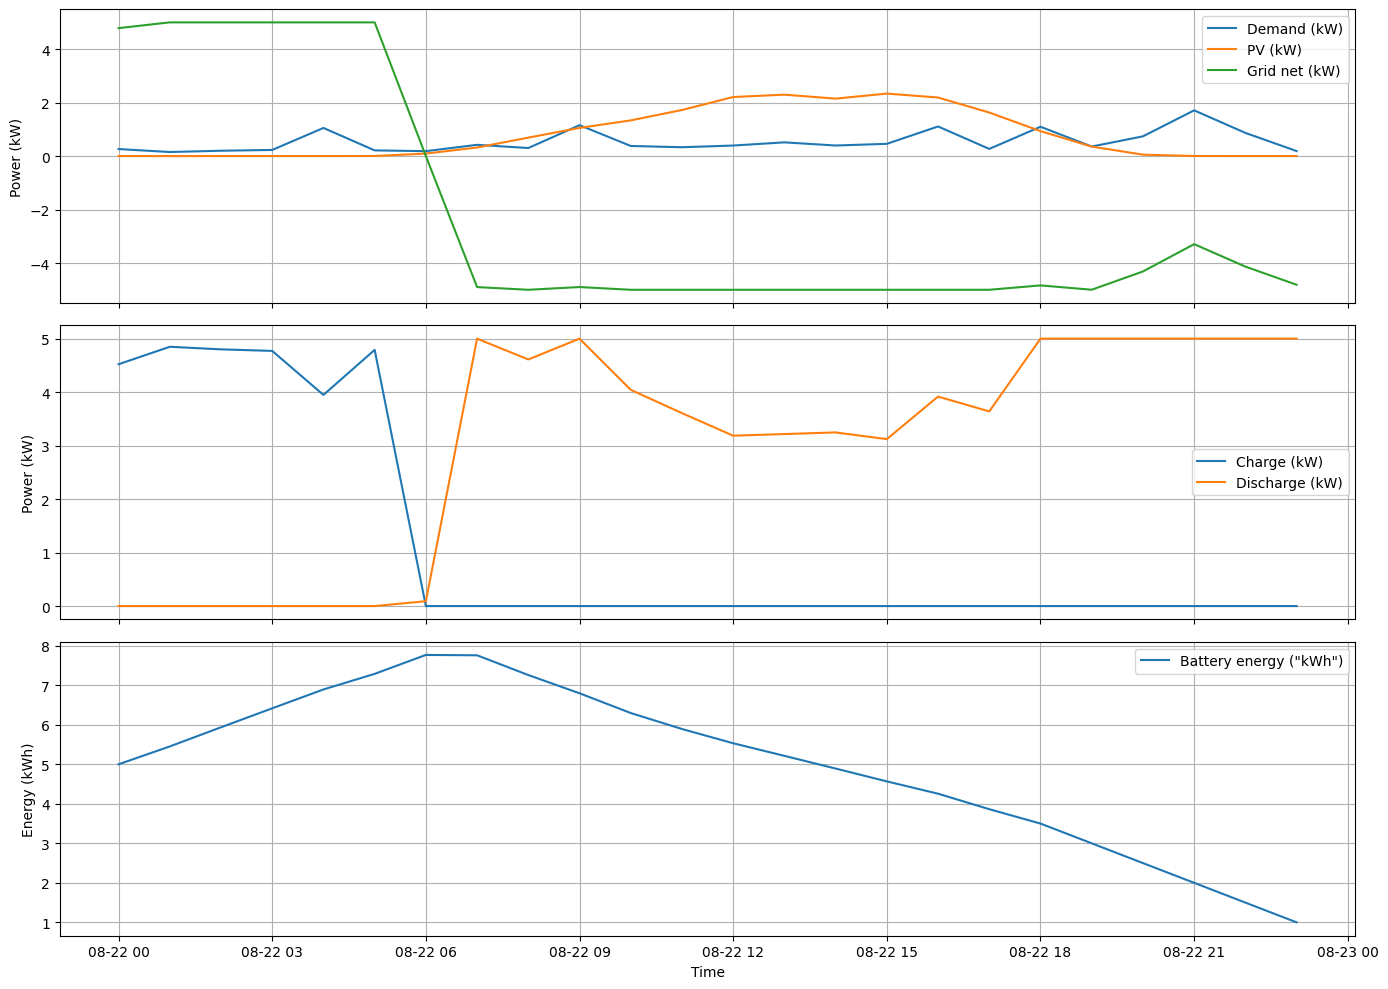

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1) Demand, PV, and net grid power
axes[0].plot(results_pyomo.index, results_pyomo["Demand_kW"], label="Demand (kW)")
axes[0].plot(results_pyomo.index, results_pyomo["PV_kW"], label="PV (kW)")
axes[0].plot(results_pyomo.index, results_pyomo["P_grid_net_kW"], label="Grid net (kW)")
axes[0].set_ylabel("Power (kW)")
axes[0].legend()

# 2) Battery charge/discharge
axes[1].plot(results_pyomo.index, results_pyomo["P_charge_kW"], label="Charge (kW)")
axes[1].plot(results_pyomo.index, results_pyomo["P_discharge_kW"], label="Discharge (kW)")
axes[1].set_ylabel("Power (kW)")
axes[1].legend()

# 3) Battery energy (kWh)
axes[2].plot(results_pyomo.index, results_pyomo["bess_kWh"], label='Battery energy ("kWh")')
axes[2].set_ylabel("Energy (kWh)")
axes[2].set_xlabel("Time")
axes[2].legend()

plt.tight_layout()
plt.show()
